In [1]:
import functions
import os
from data import data, path_map, masks, path_masks
import healpy as hp
import numpy as np

In [ ]:
# Reload functions module to get latest changes
import importlib
importlib.reload(functions)

In [2]:
# Default configuration
nside = 512
n_sim = 100
path_save = path_map + 'PYSM/'

quijote_bands = ['11']
wmap_bands = ['23', '33', '41', '61', '94']
planck_bands = ['30', '44', '70', '100', '143', '217', '353']


band_list = quijote_bands + wmap_bands + planck_bands

name_suffix = '_full_bin4-199'

# Differential Assemblies (DAs) per frequency band
BANDS = {
    'K': ['K1'],
    'Ka': ['Ka1'],
    'Q': ['Q1', 'Q2'],
    'V': ['V1', 'V2'],
    'W': ['W1', 'W2', 'W3', 'W4'],
}

lmax = 2 * nside - 1
dl = 10

mask_select = masks['QUIJOTE_galcut']['galcut10_10mk']
mask_name = mask_select['name']
use_simulated_maps = False
use_white_noise = False
use_noise = False # Use noise simulations instead of the HMDM
out_path = '/home/pablo/Desktop/master/tfm/spectra/'
path_spectra = os.path.join(out_path, f'power_spectra_{mask_name}{name_suffix}.fits')
if use_noise:
    path_hmdm_spectra = os.path.join(out_path, f'power_spectra_{mask_name}_noise_sim{name_suffix}.fits')
else:
    path_hmdm_spectra = os.path.join(out_path, f'power_spectra_{mask_name}_hmdm{name_suffix}.fits')
path_avg_std_skyplusnoise = os.path.join(out_path, f'spectra_avg_std_{mask_name}_avg_std{n_sim}_skyplusnoise{name_suffix}.fits')
path_avg_std_noise = os.path.join(out_path, f'spectra_avg_std_{mask_name}_avg_std{n_sim}_noise{name_suffix}.fits')
path_corrected_spectra = os.path.join(out_path, f'corrected_power_spectra_{mask_name}{name_suffix}.fits')

mask = hp.read_map(mask_select['path'])

#Create binning scheme
ell_1 = [4,  12, 20, 40, 60, 80, 100, 120, 140, 160, 180]
ell_2 = [11, 19, 39, 59, 79, 99, 119, 139, 159, 179, 199]

binning_params = {
    'type': 'edges',  #'linear' or 'edges'
    'lmax': lmax,
    'dl': dl,
    # For edges
    'ell1': ell_1,
    'ell2': ell_2
}

$\textbf{Part 1: Simulated maps using PySM}$

In [ ]:

# Generate maps
functions.generate_sky_maps(nside, path_save, experiment_select='QUIJOTE', band_select=quijote_bands)
functions.generate_sky_maps(nside, path_save, experiment_select='WMAP', band_select=wmap_bands)
functions.generate_sky_maps(nside, path_save, experiment_select='Planck', band_select=planck_bands)

$\textbf{Part 2: Simulated white noise maps}$

In [ ]:
functions.white_noise_maps(data, nside, experiment_select='QUIJOTE', band_select=quijote_bands, n_sim=n_sim, path_map=path_map)
functions.white_noise_maps(data, nside, experiment_select='WMAP', band_select=wmap_bands, n_sim=n_sim, path_map=path_map)
functions.white_noise_maps(data, nside, experiment_select='Planck', band_select=planck_bands, n_sim=n_sim, path_map=path_map)

$\textbf{Part 3: Build HMDM}$

In [ ]:

base_dir = os.path.dirname(data['WMAP']['23']['hmdm'])
save_path = os.path.dirname(data['WMAP']['23']['hmdm'])

combined_1to4 = functions.coadd_year_range(base_dir=base_dir, year_1=1, year_2=4, save=True, save_path=save_path)
combined_5to9 = functions.coadd_year_range(base_dir=base_dir, year_1=5, year_2=9, save=True, save_path=save_path)

In [ ]:
functions.make_hmdm(data, band_list, save=True)

$\textbf{Part 4: Build beams WMAP}$

In [ ]:
beam_path = os.path.dirname(data['WMAP']['23']['beam'])
save_path = os.path.dirname(data['WMAP']['23']['beam'])

functions.generate_band_beams(BANDS, beam_path=beam_path, save_path=save_path)

$\textbf{Part 5: Compute power spactra}$

In [ ]:
# 1. Prepare binning scheme
b = functions.create_binning(binning_params)

In [ ]:
# 2. Precompute workspaces
workspaces = functions.prepare_workspaces(mask, b, nside, lmax=lmax, purify_e=True, purify_b=True)

In [ ]:
# 3. Compute all spectra
spectra_matrix = functions.compute_all_power_spectra(
    data, band_list, mask, b,
    use_simulated_maps=use_simulated_maps,
    use_white_noise=use_white_noise,
    noise_realization=1,
    only_noise=False,
    workspaces=workspaces,
    lmax=lmax
)

# 4. Save spectra matrix into a FITS file
functions.save_spectra_to_fits(spectra_matrix, band_list, out_file=path_spectra)

In [ ]:
# 5. Compute HMDM spectra
hmdm_spectra_matrix = functions.compute_hmdm_power_spectra(
    data, band_list, mask, b, workspaces=workspaces, lmax=lmax, use_noise=use_noise
)

# 6. Save spectra matrix into a FITS file
functions.save_spectra_to_fits(hmdm_spectra_matrix, band_list, out_file=path_hmdm_spectra)

In [ ]:
# 7. Read spectra matrix from FITS
spectra_dict = functions.read_spectra_from_fits(path_spectra, band_list)

In [ ]:
# 8. Compute mean and std over noise realizations (sky + noise)
avg_std_skyplusnoise_dict = functions.average_and_std_spectra(
    data, spectra_dict, band_list, mask, b,
    use_white_noise=use_white_noise,
    n_sim=n_sim, 
    only_noise=False,
    workspaces=workspaces,
    lmax=lmax
)


functions.save_avg_std_to_fits(avg_std_skyplusnoise_dict, band_list,
                     out_file=path_avg_std_skyplusnoise,
                     use_white_noise=use_white_noise
)

# 9. Compute mean and std for noise-only maps
avg_std_noise_dict = functions.average_and_std_spectra(
    data, spectra_dict, band_list, mask, b,
    use_white_noise=use_white_noise,
    n_sim=n_sim,
    only_noise=True,
    workspaces=workspaces,
    lmax=lmax
)

functions.save_avg_std_to_fits(avg_std_noise_dict, band_list,
                     out_file=path_avg_std_noise,
                     use_white_noise=use_white_noise
)


$\textbf{Part 6: Correct power spectra}$

In [ ]:
# Path to Planck CMB spectrum (best-fit cosmology)
cmb_spectrum_file = '/home/pablo/Desktop/master/tfm/spectra/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt'

corr_spectra, out_file = functions.correct_power_spectra(
    path_spectra, path_avg_std_skyplusnoise, path_avg_std_noise,
    band_list, data, nside, 
    correct_beam=True, 
    correct_unit=True,                    # Convert to K²_RJ (Planck 2018 convention)
    correct_pixel=True, 
    save=True, 
    path_out_file=path_corrected_spectra,
    use_white_noise=use_white_noise, 
    path_hmdm_spectra=path_hmdm_spectra,
    subtract_cmb=True,                    # Subtract Planck CMB spectrum
    cmb_spectrum_path=cmb_spectrum_file   # Path to real Planck spectrum
)

$\textbf{Part 7: MCMC fitting}$

In [ ]:
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

In [ ]:
# -------------------------------
# Fitting configuration (power-law with Gaussian priors and cross-only pairs)
# -------------------------------
from functions import set_gaussian_priors

# Gaussian priors:
# - beta_s ~ N(-3.1, 0.18)  synchrotron spectral index (frequency)
# - beta_d ~ N(1.55, 0.05)  dust spectral index (frequency)
# - alpha_s ~ N(-3.0, 0.30) synchrotron ell-slope (same for EE/BB)
# - alpha_d ~ N(-2.48, 0.20) dust ell-slope (average of Planck ~-2.42 EE and ~-2.54 BB)
#   Dust temperature T_d is fixed internally at 19.6 K (effectively a delta prior).

# set_gaussian_priors({
#     'beta_s': (-3.1, 0.18),
#     'beta_d': (1.55, 0.05),
#     'alpha_s': (-3.0, 0.30),
#     'alpha_d': (-2.48, 0.20),
# })

set_gaussian_priors(None)

fitting_mode = 'power-law'

# Multipole range
ell_min = 0
ell_max = 200

# Sampler configuration
nwalkers = 200
ninter = 25000
discard_fraction = 0.5

# Components to fit in the power-law model
fit_components = (
    'sync',
    'dust',
    'cross'
)

# # Build cross-only band pairs across all bands (exclude autos)
# band_pairs_cross_all = []
# for i in range(len(band_list)):
#     for j in range(i + 1, len(band_list)):
#         band_pairs_cross_all.append(f"{band_list[i]}_{band_list[j]}")

# # Use cross-only pairs
# band_pairs = band_pairs_cross_all

band_pairs = 'all'

fit_c_terms = False

# Save paths for corner plots
components_str = '_'.join(fit_components)
save_path_EE = f'/home/pablo/Desktop/master/tfm/figures/corner/corner_{components_str}_EE{name_suffix}.pdf'
save_path_BB = f'/home/pablo/Desktop/master/tfm/figures/corner/corner_{components_str}_BB{name_suffix}.pdf'

# Load corrected spectra
spectra_dict = functions.read_corrected_cls(path_corrected_spectra, band_list)

In [ ]:
# Prepare EE data and run MCMC (power-law with prior and cross-only pairs)
fit_data_EE = functions.prepare_mcmc_data(
    spectra_dict,
    band_list=band_list,
    modes=['EE'],
    ell_min=ell_min,
    ell_max=ell_max,
    band_pairs=band_pairs
)

sampler_EE, samples_full_EE, samples_free_EE, param_map_EE, chi2_reduced_EE = functions.run_mcmc(
    fit_data=fit_data_EE,
    fit_components=fit_components,
    fit_c_terms=fit_c_terms,
    nwalkers=nwalkers,
    ninter=ninter,
    discard_fraction=discard_fraction,
    verbose=True,  # Show progress bar
    fit_mode=fitting_mode
)

print(f'Reduced chi^2 (EE) = {chi2_reduced_EE}')

In [ ]:
# Plot and save the corner plot
fig_EE = functions.plot_corner(samples_free_EE, param_map_EE, save_path_EE, title=f'EE Mode')

In [ ]:
# Prepare BB data and run MCMC (power-law with prior and cross-only pairs)
fit_data_BB = functions.prepare_mcmc_data(
    spectra_dict,
    band_list=band_list,
    modes=['BB'],
    ell_min=ell_min,
    ell_max=ell_max,
    band_pairs=band_pairs
)

# Run MCMC with the selected fitting mode
sampler_BB, samples_full_BB, samples_free_BB, param_map_BB, chi2_reduced_BB = functions.run_mcmc(
    fit_data=fit_data_BB,
    fit_components=fit_components,
    fit_c_terms=fit_c_terms,
    nwalkers=nwalkers,
    ninter=ninter,
    discard_fraction=discard_fraction,
    verbose=True,  # Show progress bar
    fit_mode=fitting_mode
)

print(f'Reduced chi^2 (BB) = {chi2_reduced_BB}')

In [ ]:
# Plot and save the corner plot
fig_BB = functions.plot_corner(samples_free_BB, param_map_BB, save_path_BB, title=f'BB Mode')

$\textbf{Part 8: Bin to bin fitting}$

In [3]:
# Configuration for bin-to-bin fitting (Gaussian priors + cross-only pairs)
from functions import set_gaussian_priors

# Apply the same Gaussian priors:
# - beta_s ~ N(-3.1, 0.18)
# - beta_d ~ N(1.55, 0.05)
# - alpha_s ~ N(-3.0, 0.30)
# - alpha_d ~ N(-2.48, 0.20)  (average of Planck alpha_EE ~ -2.42 and alpha_BB ~ -2.54)
#   T_d fixed at 19.6 K inside the dust scaling (implicit delta prior)
set_gaussian_priors({
    'beta_s': (-3.1, 0.30),
    # 'beta_d': (1.55, 0.05),
    # 'alpha_s': (-3.0, 0.30),
    # 'alpha_d': (-2.48, 0.20),
})

fit_mode_btb = 'bin-to-bin'  # Use 'bin-to-bin' mode

# Multipole range
ell_min_btb = 0
ell_max_btb = 200

# Sampler configuration
nwalkers_btb = 100
ninter_btb = 15000
discard_fraction_btb = 0.5

# Fit synchrotron, dust, and cross components per bin
fit_components_btb = ('sync', 'dust', 'cross')

# # Build cross-only band pairs across all bands (exclude autos)
# band_pairs_cross_all = []
# for i in range(len(band_list)):
#     for j in range(i + 1, len(band_list)):
#         band_pairs_cross_all.append(f"{band_list[i]}_{band_list[j]}")

# band_pairs_btb = band_pairs_cross_all

band_pairs_btb = 'all'

# Load corrected spectra
spectra_dict_btb = functions.read_corrected_cls(path_corrected_spectra, band_list)

In [4]:
# Prepare EE data and run bin-to-bin MCMC (cross-only pairs)
fit_data_EE = functions.prepare_mcmc_data(
    spectra_dict_btb,
    band_list=band_list,
    modes=['EE'],
    ell_min=ell_min_btb,
    ell_max=ell_max_btb,
    band_pairs=band_pairs_btb
)

# Run bin-to-bin MCMC for EE mode
samplers_EE, samples_full_EE, samples_free_EE, param_names_btb, chi2_reduced_EE = functions.run_mcmc(
    fit_data=fit_data_EE,
    fit_components=fit_components_btb,
    fit_c_terms=False,
    nwalkers=nwalkers_btb,
    ninter=ninter_btb,
    discard_fraction=discard_fraction_btb,
    verbose=True,
    fit_mode=fit_mode_btb
)

[run_mcmc bin-to-bin] Fitting 11 ell bins independently
[run_mcmc bin-to-bin] Parameters per bin: ['A_s', 'beta_s', 'A_d', 'beta_d', 'rho']
[run_mcmc bin-to-bin] Available cores: 16
[run_mcmc bin-to-bin] Using 16 cores for walker parallelization

[run_mcmc bin-to-bin] Processing bin 1/11 (ell=7.0)


100%|██████████| 15000/15000 [23:02<00:00, 10.85it/s]


[run_mcmc bin-to-bin] Bin 1 completed. χ²_red = 1.1602

[run_mcmc bin-to-bin] Processing bin 2/11 (ell=15.0)


100%|██████████| 15000/15000 [23:15<00:00, 10.75it/s]


[run_mcmc bin-to-bin] Bin 2 completed. χ²_red = 1.5489

[run_mcmc bin-to-bin] Processing bin 3/11 (ell=29.0)


...

[run_mcmc bin-to-bin] Bin 9 completed. χ²_red = 1.0932

[run_mcmc bin-to-bin] Processing bin 10/11 (ell=169.0)


100%|██████████| 15000/15000 [20:29<00:00, 12.20it/s]

[run_mcmc bin-to-bin] Bin 10 completed. χ²_red = 0.9332

[run_mcmc bin-to-bin] Processing bin 11/11 (ell=189.0)



100%|██████████| 15000/15000 [20:18<00:00, 12.31it/s]

[run_mcmc bin-to-bin] Bin 11 completed. χ²_red = 1.1918

[run_mcmc bin-to-bin] All 11 bins completed successfully
[run_mcmc bin-to-bin] Mean χ²_red = 1.2224 ± 0.2684


In [5]:
# Prepare BB data and run bin-to-bin MCMC (cross-only pairs)
fit_data_BB = functions.prepare_mcmc_data(
    spectra_dict_btb,
    band_list=band_list,
    modes=['BB'],
    ell_min=ell_min_btb,
    ell_max=ell_max_btb,
    band_pairs=band_pairs_btb
)

# Run bin-to-bin MCMC for BB mode
samplers_BB, samples_full_BB, samples_free_BB, param_names_btb, chi2_reduced_BB = functions.run_mcmc(
    fit_data=fit_data_BB,
    fit_components=fit_components_btb,
    fit_c_terms=False,
    nwalkers=nwalkers_btb,
    ninter=ninter_btb,
    discard_fraction=discard_fraction_btb,
    verbose=True,
    fit_mode=fit_mode_btb
)

[run_mcmc bin-to-bin] Fitting 11 ell bins independently
[run_mcmc bin-to-bin] Parameters per bin: ['A_s', 'beta_s', 'A_d', 'beta_d', 'rho']
[run_mcmc bin-to-bin] Available cores: 16
[run_mcmc bin-to-bin] Using 16 cores for walker parallelization

[run_mcmc bin-to-bin] Processing bin 1/11 (ell=7.0)


100%|██████████| 15000/15000 [23:07<00:00, 10.81it/s]


[run_mcmc bin-to-bin] Bin 1 completed. χ²_red = 0.8601

[run_mcmc bin-to-bin] Processing bin 2/11 (ell=15.0)


100%|██████████| 15000/15000 [23:15<00:00, 10.75it/s]


[run_mcmc bin-to-bin] Bin 2 completed. χ²_red = 1.0617

[run_mcmc bin-to-bin] Processing bin 3/11 (ell=29.0)


...

[run_mcmc bin-to-bin] Bin 9 completed. χ²_red = 1.2481

[run_mcmc bin-to-bin] Processing bin 10/11 (ell=169.0)



100%|██████████| 15000/15000 [21:41<00:00, 11.53it/s]


[run_mcmc bin-to-bin] Bin 10 completed. χ²_red = 1.5921

[run_mcmc bin-to-bin] Processing bin 11/11 (ell=189.0)


100%|██████████| 15000/15000 [20:28<00:00, 12.21it/s]

[run_mcmc bin-to-bin] Bin 11 completed. χ²_red = 1.8167

[run_mcmc bin-to-bin] All 11 bins completed successfully
[run_mcmc bin-to-bin] Mean χ²_red = 1.4084 ± 0.2752


In [6]:
table_save_path_latex = f'/home/pablo/Desktop/master/tfm/tables/bin_to_bin_results{name_suffix}.tex'

# Generate LaTeX table
table_latex = functions.create_bin_to_bin_table(
    fit_data_EE=fit_data_EE,
    fit_data_BB=fit_data_BB,
    samples_free_list_EE=samples_free_EE,
    samples_free_list_BB=samples_free_BB,
    param_names=param_names_btb,
    ell1=ell_1,
    ell2=ell_2,
    save_path=table_save_path_latex,
    format='latex'
)

# Generate ASCII table for quick viewing
table_ascii = functions.create_bin_to_bin_table(
    fit_data_EE=fit_data_EE,
    fit_data_BB=fit_data_BB,
    samples_free_list_EE=samples_free_EE,
    samples_free_list_BB=samples_free_BB,
    param_names=param_names_btb,
    ell1=ell_1,
    ell2=ell_2,
    save_path=None,
    format='ascii'
)

print(table_ascii)

[create_bin_to_bin_table] Table saved to: /home/pablo/Desktop/master/tfm/tables/bin_to_bin_results_full_bin4-199.tex
Bin-to-bin fit results
EE mode (top) and BB mode (bottom)
For BB mode, amplitudes A_s and A_d are shown in the same units as EE
 ell range   | ell_eff  |        A_s_EE        |      beta_s_EE       |        A_d_EE        |      beta_d_EE       |        rho_EE        |
------------------------------------------------------------------------------------------------------------------------------------------------------
   4--11     |   7.0    |    814.04 ± 189.74    |     -3.01 ± 0.15      |   3546.06 ± 136.25    |      1.49 ± 0.05      |     0.164 ± 0.061     |
   12--19    |   15.0   |    124.31 ± 6.46      |     -3.04 ± 0.04      |    338.79 ± 3.83      |      1.47 ± 0.01      |     0.169 ± 0.015     |
   20--39    |   29.0   |     27.32 ± 0.78      |     -3.09 ± 0.02      |     45.06 ± 0.33      |      1.45 ± 0.01      |     0.070 ± 0.008     |
   40--59    |   49.0   |

[plot_bin_to_bin_results] Figure saved to: /home/pablo/Desktop/master/tfm/figures/bin_to_bin_evolution_full_bin4-199.pdf


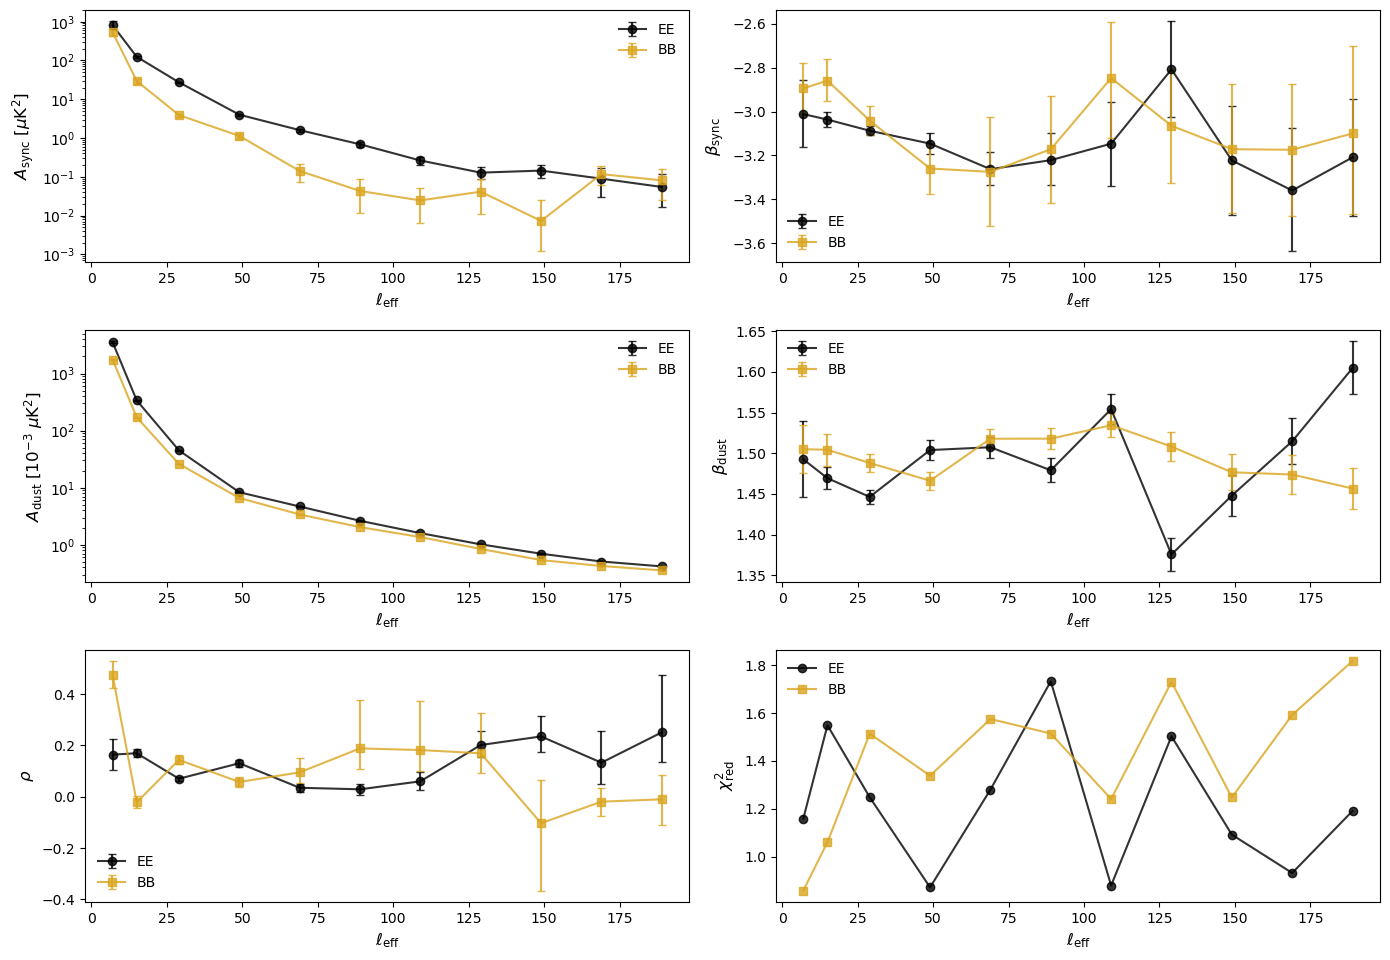

In [7]:
# Plot parameter evolution with ell
plot_save_path = f'/home/pablo/Desktop/master/tfm/figures/bin_to_bin_evolution{name_suffix}.pdf'

fig = functions.plot_bin_to_bin_results(
    fit_data_EE=fit_data_EE,
    fit_data_BB=fit_data_BB,
    samples_free_list_EE=samples_free_EE,
    samples_free_list_BB=samples_free_BB,
    param_names=param_names_btb,
    chi2_reduced_EE=chi2_reduced_EE,
    chi2_reduced_BB=chi2_reduced_BB,
    save_path=plot_save_path,
    figsize=(14, 10)
)

$\textbf{Convergence check for bin-to-bin}$

[plot_bin_to_bin_convergence] Figure saved to: /home/pablo/Desktop/master/tfm/figures/bin_to_bin_convergence_full_bin4-199.pdf


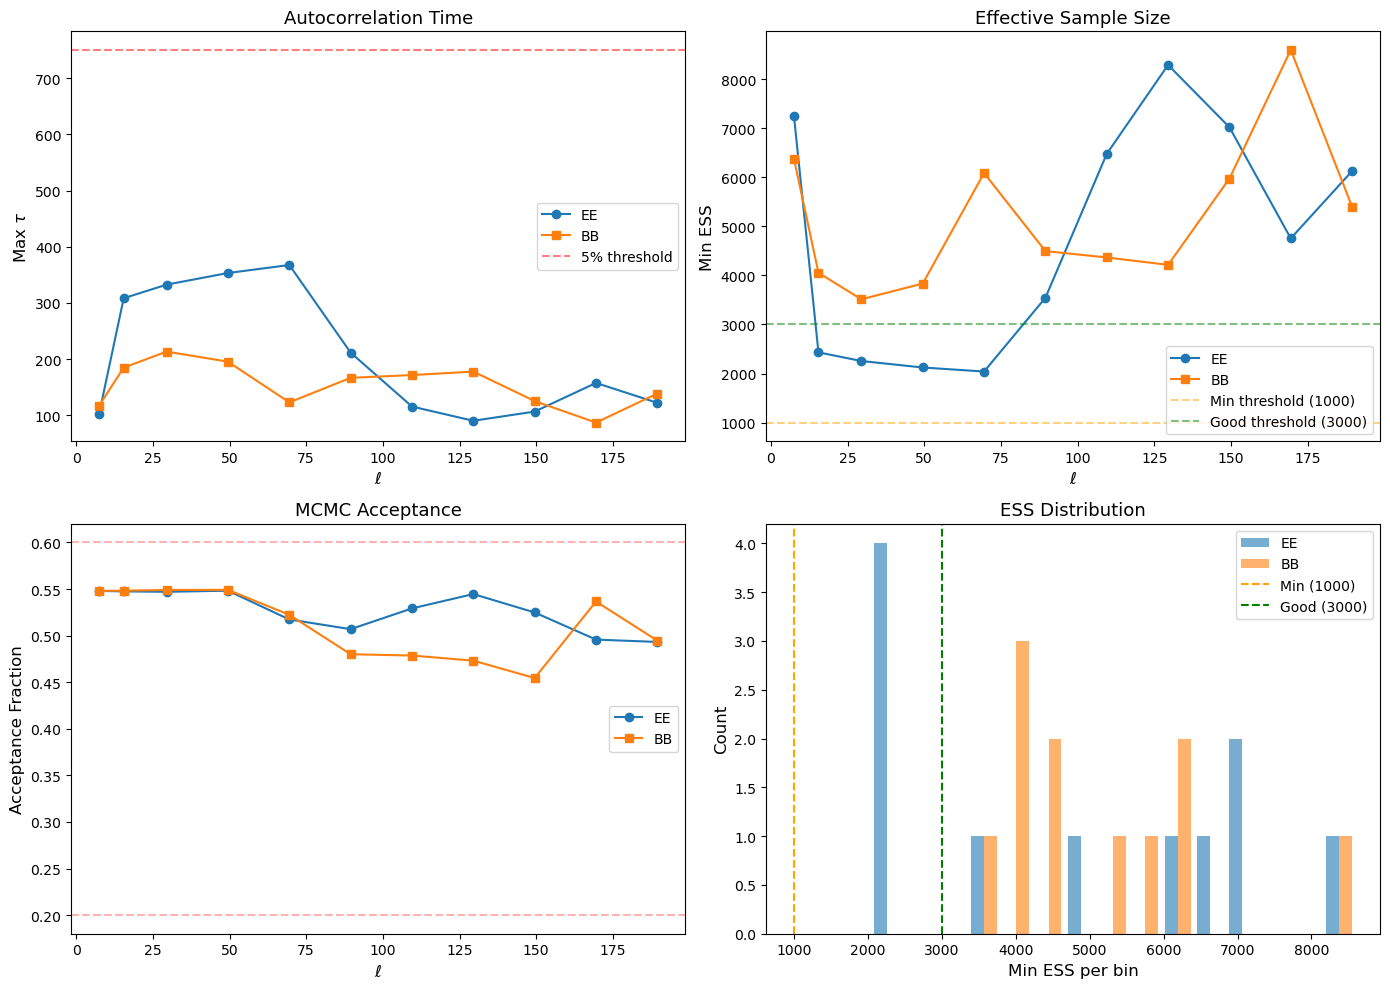

In [8]:
convergence_save_path = f'/home/pablo/Desktop/master/tfm/figures/bin_to_bin_convergence{name_suffix}.pdf'

fig_convergence = functions.plot_bin_to_bin_convergence(
    samplers_EE=samplers_EE,
    samplers_BB=samplers_BB,
    ell_1=ell_1,
    ell_2=ell_2,
    ninter=ninter_btb,
    discard_fraction=discard_fraction_btb,
    save_path=convergence_save_path,
    figsize=(14, 10)
)